In [1]:
#1. Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
#2. Load the dataset

df = pd.read_csv("AirTemp.csv")
df.head()

,Date,T
0,3/10/2004,13.6
1,3/10/2004,13.3
2,3/10/2004,11.9
3,3/10/2004,11.0
4,3/10/2004,11.2


In [3]:
#3. Clean invalid values

df = df[df["T"] != -200]

In [4]:
#4. Convert Date column to datetime & extract Month

df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

In [5]:
#5. Check correlation

df[["Month", "T"]].corr()

,Month,T
Month,1.000000,0.282929
T,0.282929,1.000000


In [6]:
#6. Prepare Variables

X = df[["Month"]]   # predictor
y = df["T"]         # target


In [7]:
#7. Train Linear Regression Model

model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [8]:
#8. Predict

y_pred = model.predict(X)

In [9]:
#9. Compute R², MSE, RMSE

R2 = model.score(X, y)
MSE = mean_squared_error(y, y_pred)
RMSE = np.sqrt(MSE)

print("R²:", R2)
print("MSE:", MSE)
print("RMSE:", RMSE)

R²: 0.08004887126875881
MSE: 71.75397303905719
RMSE: 8.470771690882549


In [10]:
#10. Show Model Coefficients

print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): 0.7332658165850969
Intercept: 13.67788987843667


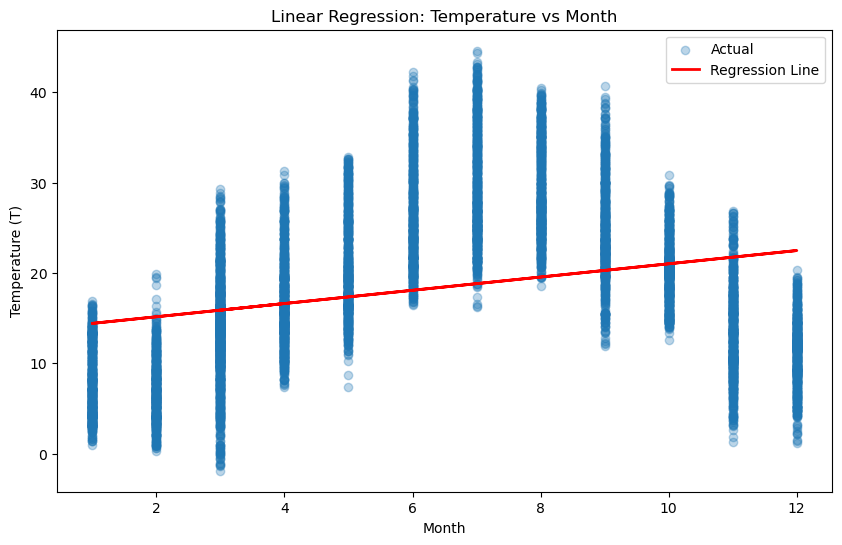

In [11]:
#11. Plot Regression Line

plt.figure(figsize=(10,6))
plt.scatter(df["Month"], y, alpha=0.3, label="Actual")
plt.plot(df["Month"], y_pred, color="red", linewidth=2, label="Regression Line")

plt.title("Linear Regression: Temperature vs Month")
plt.xlabel("Month")
plt.ylabel("Temperature (T)")
plt.legend()
plt.show()